# Chpater2. 사이킷런으로 시작하는 머신러닝

In [2]:
import sklearn
print(sklearn.__version__)

1.2.2


## 02. 첫번째 머신러닝 만들어보기_붓꽃 품종 예측하기

- 분류: 지도학습 방법
피처 분류 결정값인 레이블 데이터로 모델 학습한 뒤, 별도 테스트 데이터 셋에서 미지의 레이블 예측

In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [4]:
import pandas as pd

iris=load_iris() #데이터셋 로딩

iris_data=iris.data #iris_data는 피처만으로된 데이터 넘파이를 가짐

iris_label=iris.target #iris_target은 결정값(레이블)데이터를 넘파이로 가짐
print('iris target값:',iris_label)
print('iris target명:',iris.target_names)

iris_df=pd.DataFrame(data=iris_data,columns=iris.feature_names) #dataframe으로 변환
iris_df['label']=iris.target
iris_df.head(3)

iris target값: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
iris target명: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


- 피처: sepal length,sepal width,petal length,petal width
- 레이블(결정값): 0 - setosa품종, 1- versicolor품종, 2-virginica품종

In [5]:
X_train,X_test,y_train,y_test=train_test_split(iris_data,iris_label,test_size=0.2,random_state=11)

- train_test_split(): 학습,테스트 데이터를 test_size파라미터 입력값의 비율로 쉽게 분할 test_size가 0.2면 테스트 데이터 20%,학습데이터 80%로 분할

- 학습용 피처 데이터셋:X_train, 테스트용 피처 데이터셋 :X_test,학습용 레이블 데이터셋:y_train,테스트용 레이블 데이터셋 y_test로 반환

In [7]:
# decisiontreeclassifirer객체생성
dt_clf=DecisionTreeClassifier(random_state=11)

In [8]:
#학습수행
dt_clf.fit(X_train,y_train)

DecisionTreeClassifier(random_state=11)

In [9]:
#학습완료된 decisionTreeClassifier객체에서 테스트 데이터셋으로 예측
pred=dt_clf.predict(X_test)

- 정확도: 예측 결과가 실제 레이블값과 얾나ㅏ 정확하게 맞는 지 평가하는 지표

In [11]:
from sklearn.metrics import accuracy_score
print('예측정확도:{0:.4f}'.format(accuracy_score(y_test,pred)))

예측정확도:0.9333


## 03. 사이킷런의 기반 프레임워크 익히기

- estimator이해, fit(),predict() 메서드

fit():ML모델 학습을 위해 사용
predict():학습된 모델의 예측을 위해 사용
회귀와 분류를 합쳐 estimator클래스라고 부름

사이킷 런에 저장된 데이터셋은 일반적으로 딕셔너리 형태

data: 피처의 데이터셋가르킴, target_분류 시 레이블 값,회귀일 때는 숫자 결괏값 데이터 세트, target_names는 개별 레이블의 이름을 나타냄, feature_names 피처의 이름을 나타냄, DESCR 데이터 셋에 대한 설명, 피처의 설명을 나타냄

In [13]:
from sklearn.datasets import load_iris

iris_data=load_iris()
print(type(iris_data))


<class 'sklearn.utils._bunch.Bunch'>


- Bunnch 클래스는 파이썬 딕셔너리 자료형과 유사함

In [15]:
keys=iris_data.keys()
print('붓꽃 데이터 세트의 키들:',keys)

붓꽃 데이터 세트의 키들: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [16]:
print('\n feature_names의 type:',type(iris_data.feature_names))
print('feature_names의 shpae:',len(iris_data.feature_names))
print(iris_data.feature_names)

print('\n target_names의  type:',type(iris_data.target_names))


 feature_names의 type: <class 'list'>
feature_names의 shpae: 4
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

 target_names의  type: <class 'numpy.ndarray'>


In [17]:
print('target_names의 shape:',len(iris_data.target_names))
print(iris_data.target_names)

print('\n data의 type:',type(iris_data.data))
print('data의 shape:',iris_data.data.shape)
print(iris_data['data'])

print('\n target의 type:',type(iris_data.target))
print('target의 shape:',iris_data.target.shape)
print(iris_data.target)

target_names의 shape: 3
['setosa' 'versicolor' 'virginica']

 data의 type: <class 'numpy.ndarray'>
data의 shape: (150, 4)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3

## 04. Model Selection 모듈 소개

- model selection 모듈은 학습/테스트 데이터 셋 분리하거나 교차 검증 분할 및 평가, estimator의 하이퍼 파라미터를 튜닝하기 위한 다양한 함수,클래스를 제공

In [21]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

iris=load_iris()
dt_clf=DecisionTreeClassifier()
train_data=iris.data
train_label=iris.target
dt_clf.fit(train_data,train_label)

pred=dt_clf.predict(train_data)
print('예측 정확도:',accuracy_score(train_label,pred))

예측 정확도: 1.0


정확도가 100%인 이유: 이미학습한거 기반으로 예측해서(모고 답아는 상태로 같은 모고 푼 느낌)

- 예측 수행하는 데이터셋은 학습 수행한 학습용 데이터 셋이 아닌 테스트 데이터셋이어야 함

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

dt_clf=DecisionTreeClassifier()
iris_data=load_iris()

X_train,X_test,y_train,y_test=train_test_split(iris_data.data,iris_data.target,test_size=0.3,random_state=121)

-> 테스트 데이터셋 30%, 학습 데이터셋 70%로 분리, random_state=121

In [27]:
dt_clf.fit(X_train, y_train)
pred=dt_clf.predict(X_test)
print('예측 정확도:{0:.4f}'.format(accuracy_score(y_test,pred)))

예측 정확도:0.9556


붓꽃 데이터는 150개의 데이터 -> 양이 크지 않아 전체 30%면 45개뿐임.. -> 이걸로 알고리즘 예측 성능 판단하기 좋지x

### 교차 검증

overfitting의 약점을 보완하기 위해 교차검증 필요

데이터 편중을 막기 위해 별도의 여러셋으로 구성된 학습 데이터,검증 데이터 셋에서 학습과 평가를 수행하는 것

평가 결과에 따라 하이퍼 파라미터 튜닝 등 모델 최적화를 더욱 손쉽게 할 수 o

대부분 ML모델의 성능평가는 교차검증 기반으로 1차 평가 후 최종적으로 테스트 데이터셋에 적용해 평가

- 학습 데이터셋,검증데이터셋(최종 평가 이전 학습된 모델 다양하게 평가하는데 사용함),테스트 데이터셋

### K폴드 교차 검증

k개의 데이터 폴드 셋 만들어 k번 만큼 각 폴드 세트에 학습,검증 평가를 반복적으로 수행하는 방법

- 학습 데이터셋과 검증 데이터셋을 점진적으로 변경하면서 마지막 k번째 까지 학습,검증을 수행하는 것

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import numpy as np

iris=load_iris()
features=iris.data
label=iris.target
dt_clf=DecisionTreeClassifier(random_state=156)

kfold=KFold(n_splits=5)
cv_accuracy=[]
print('붓꽃 데이터 셋 크기:',features.shape[0])

붓꽃 데이터 셋 크기: 150


In [36]:
n_iter =0

for train_index,test_index in kfold.split(features):
    X_train,X_test=features[train_index],features[test_index]
    y_train,y_test=label[train_index],label[test_index]

    dt_clf.fit(X_train, y_train)
    pred=dt_clf.predict(X_test)
    n_iter +=1

    accuracy=np.round(accuracy_score(y_test,pred),4)
    train_size=X_train.shape[0]
    test_size=X_test.shape[0]
    print('\n#{0} 교차 검증 정확도:{1}, 학습데이터크기:{2},검증 데이터 크기:{3}'.format(n_iter,accuracy,train_size,test_size))
    print('#{0}검증 세트 인덱스:{1}'.format(n_iter,test_index))
    cv_accuracy.append(accuracy)

print('\n##평균 검증 정확도:',np.mean(cv_accuracy))


#1 교차 검증 정확도:1.0, 학습데이터크기:120,검증 데이터 크기:30
#1검증 세트 인덱스:[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]

#2 교차 검증 정확도:0.9667, 학습데이터크기:120,검증 데이터 크기:30
#2검증 세트 인덱스:[30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53
 54 55 56 57 58 59]

#3 교차 검증 정확도:0.8667, 학습데이터크기:120,검증 데이터 크기:30
#3검증 세트 인덱스:[60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83
 84 85 86 87 88 89]

#4 교차 검증 정확도:0.9333, 학습데이터크기:120,검증 데이터 크기:30
#4검증 세트 인덱스:[ 90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119]

#5 교차 검증 정확도:0.7333, 학습데이터크기:120,검증 데이터 크기:30
#5검증 세트 인덱스:[120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137
 138 139 140 141 142 143 144 145 146 147 148 149]

##평균 검증 정확도: 0.9


### Stratified K폴드

불균형한 분포도를 가진 레이블 데이터 집합을 위한 K폴드 방식

ex.대출 사기 데이터 예측 -> 대부분 정상, 작은 확률로 사기 레이블일 것

K폴드가 레이블데이터 집합이 원본 데이터 집합의 레이블 분포를 학습,테스트 세트에 제대로 분배하지 못하는 경우를 해결해줌

원본 데이터의 레이블 분포를 먼저 고려-> 분포와 동일하게 학습,검증 데이터 셋을 분배

In [37]:
import pandas as pd
iris=load_iris()
iris_df=pd.DataFrame(data=iris.data,columns=iris.feature_names)
iris_df['label']=iris.target
iris_df['label'].value_counts()

label
0    50
1    50
2    50
Name: count, dtype: int64

- 레이블값 모두 50개로 동일

이슈 발생시키기 위해 kfold로 생성, 교차 검증시마다 생성되는 학습/검증 데이터 값의 분포도 확인

In [41]:
kfold=KFold(n_splits=3)
n_iter=0
for train_index,test_index in kfold.split(iris_df):
    n_iter +=1
    label_train=iris_df['label'].iloc[train_index]
    label_test=iris_df['label'].iloc[test_index]
    print('##교차검증:{0}'.format(n_iter))
    print('학습 레이블 데이터분포:\n',label_train.value_counts())
    print('검증 레이블 데이터 분포:\n',label_test.value_counts())

##교차검증:1
학습 레이블 데이터분포:
 label
1    50
2    50
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
0    50
Name: count, dtype: int64
##교차검증:2
학습 레이블 데이터분포:
 label
0    50
2    50
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
1    50
Name: count, dtype: int64
##교차검증:3
학습 레이블 데이터분포:
 label
0    50
1    50
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
2    50
Name: count, dtype: int64


- stratifiedKFold는 KFold로 분할된 레이블 데이터셋이 전체 레이블값의 분포도를 반영하지 못하는 문제를 해결해줌

In [42]:
from sklearn.model_selection import StratifiedKFold

skf=StratifiedKFold(n_splits=3)
n_iter=0

for train_index,test_index in skf.split(iris_df,iris_df['label']):
    n_iter+=1
    label_train=iris_df['label'].iloc[train_index]
    label_test=iris_df['label'].iloc[test_index]
    print('##교차검증:{0}'.format(n_iter))
    print('학습 레이블 데이터 분포:\n',label_train.value_counts())
    print('검증 레이블 데이터 분포:\n',label_test.value_counts())

##교차검증:1
학습 레이블 데이터 분포:
 label
2    34
0    33
1    33
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
0    17
1    17
2    16
Name: count, dtype: int64
##교차검증:2
학습 레이블 데이터 분포:
 label
1    34
0    33
2    33
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
0    17
2    17
1    16
Name: count, dtype: int64
##교차검증:3
학습 레이블 데이터 분포:
 label
0    34
1    33
2    33
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
1    17
2    17
0    16
Name: count, dtype: int64


In [47]:
# 데이터 분리
dt_clf=DecisionTreeClassifier(random_state=156)

skfold=StratifiedKFold(n_splits=3)
n_iter=0
cv_accuracy=[]

for train_index,test_index in skfold.split(features,label):
    X_train,X_test=features[train_index],features[test_index]
    y_train,y_test=label[train_index],label[test_index]

    dt_clf.fit(X_train,y_train)
    pred=dt_clf.predict(X_test)

    n_iter +=1
    accuracy=np.round(accuracy_score(y_test,pred),4)
    train_size=X_train.shape[0]
    test_size=X_test.shape[0]
    print('\n#{0} 교차 검증 정확도:{1}, 학습데이터 크기:{2},검증데이터크기:{3}'.format(n_iter,accuracy,train_size,test_size))
    print('#{0} 검증 세트 인덱스:{1}'.format(n_iter,test_index))
    cv_accuracy.append(accuracy)
print('\n## 교차 검증별 정확도:',np.round(cv_accuracy,4))
print('## 평균 검증 정확도:',np.round(np.mean(cv_accuracy),4))


#1 교차 검증 정확도:0.98, 학습데이터 크기:100,검증데이터크기:50
#1 검증 세트 인덱스:[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  50
  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66 100 101
 102 103 104 105 106 107 108 109 110 111 112 113 114 115]

#2 교차 검증 정확도:0.94, 학습데이터 크기:100,검증데이터크기:50
#2 검증 세트 인덱스:[ 17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  67
  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82 116 117 118
 119 120 121 122 123 124 125 126 127 128 129 130 131 132]

#3 교차 검증 정확도:0.98, 학습데이터 크기:100,검증데이터크기:50
#3 검증 세트 인덱스:[ 34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  83  84
  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149]

## 교차 검증별 정확도: [0.98 0.94 0.98]
## 평균 검증 정확도: 0.9667


### 교차 검증을 보다 간편하게  - cross_val_score()

KFold로 데이터 학습,예측하는 코드
1) 폴드세트 설정, 2)for루프에서 반복으로 학습,테스트 데이터의 인덱스 추출 3) 반복적으로 학습과 예측을 수행,예측 성능을 반환

- cross_val_score()는 이런 과정을 한꺼번에 수행해주는 API

선언 형태 : cross_val_score(estimator,X,y=None,scoring=None,cv=None,n_jobs=1,verbose=0,fit_params=None,pre_dispatch='2*n_jobs')

scoring:예측 성능 평가 지표,cv: 교차 검증 폴드 수

- cross_val_score()수행 후 반환 값은 scoring파라미터로 지정된 성능 지표 측정값을 배열형태로 반환

- corss_val_score()은 classfier가 입력되면 stratifiedK폴드 방식으로 레이블 값의 분포따라 학습/테스트셋 분할함(회귀일땐 K폴드방식)

In [49]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score,cross_validate
from sklearn.datasets import load_iris

iris_data=load_iris()
dt_clf=DecisionTreeClassifier(random_state=156)

data=iris_data.data
label=iris_data.target

scores=cross_val_score(dt_clf,data,label,scoring='accuracy',cv=3)
print('교차 검증별 정확도:',np.round(scores,4))
print('평균 검증 정확도:',np.round(np.mean(scores),4))

교차 검증별 정확도: [0.98 0.94 0.98]
평균 검증 정확도: 0.9667


cv로 지정된 횟수 만큼 scoring 파라미터로 지정된 평가 지표로 평가 결괏값을 배열로 반환함
일반적으로 이를 평균해 평가 수치로 사용

api는 내부에서 estimator을 학습,예측,평가 시켜주므로 간단하게 교차검증할 수 o

- cross_validate(): 여러개의 평가 지표를 반환, 성능평가지표,수행시간도 함께 제공
- cross_val_score(): 하나의 평가지표만 가능

### GridSearchCV - 교차 검증,최적 하이퍼 파라미터 튜닝을 한번에

머신라닝 알고리즘을 구성하는 주요 구성 요소, 이값을 조정해 알고리즘의 예측 성능을 개선할 수 o

gridsearch cv api를 이용해 분류/회귀같은 알고리즘에 사용되는 하이퍼 파라미터를 순차적 입력> 최적의 파라미터 쉽게 도출가능

In [52]:
grid_parameters={'max_depth':[1,2,3],
                 'min_samples_split':[2,3]
                }

- 교차 검증을 기반으로 하이퍼 파라미터의 최적값을 찾게 해줌
데이터셋을 cross_validation을 위한 학습/테스트셋으로 자동 분할>모든 파라미터 순차적 적용-> 최적의 파라미터를 찾아줌

but 시간이 오래 걸릴 수 있음

- refit:트루로 생성시 가장 최적의 하이퍼 파라미터 찾은 뒤 입력된 estimator객체를 해당 하이퍼 파라미터로 재학습시킴

In [33]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

iris_data=load_iris()
X_train,X_test,y_train,y_test=train_test_split(iris_data.data,iris_data.target,test_size=0.2,random_state=121)

dtree=DecisionTreeClassifier()

parameters={'max_depth':[1,2,3],'min_samples_split':[2,3]}

In [34]:
import pandas as pd
grid_dtree=GridSearchCV(dtree,param_grid=parameters,cv=3,refit=True)

In [35]:
grid_dtree.fit(X_train,y_train)
scores_df=pd.DataFrame(grid_dtree.cv_results_)
scores_df[['params','mean_test_score','rank_test_score','split0_test_score','split1_test_score','split2_test_score']]

,params,mean_test_score,rank_test_score,split0_test_score,split1_test_score,split2_test_score
0,"{'max_depth': 1, 'min_samples_split': 2}",0.700000,5,0.700,0.7,0.70
1,"{'max_depth': 1, 'min_samples_split': 3}",0.700000,5,0.700,0.7,0.70
2,"{'max_depth': 2, 'min_samples_split': 2}",0.958333,3,0.925,1.0,0.95
3,"{'max_depth': 2, 'min_samples_split': 3}",0.958333,3,0.925,1.0,0.95
4,"{'max_depth': 3, 'min_samples_split': 2}",0.975000,1,0.975,1.0,0.95
5,"{'max_depth': 3, 'min_samples_split': 3}",0.975000,1,0.975,1.0,0.95


 - params: 수행할때마다 적용된 개별 하이퍼 파라미터값
- rank_test_score:하이퍼 파라미터별로 성능이 좋은 score순위, 1>>>>>'' 1이 최적의 하이퍼 파라미터
- mean_test_score:개별 하이퍼 파라미터별로 CV의 폴딩 테스트 세트에 총 수행한 평가 평균값

In [36]:
print('GridSearchCV 최적 파라미터:',grid_dtree.best_params_)
print('GridSearchCV 최고 정확도:{0:.4f}'.format(grid_dtree.best_score_))

GridSearchCV 최적 파라미터: {'max_depth': 3, 'min_samples_split': 2}
GridSearchCV 최고 정확도:0.9750


In [37]:
estimator=grid_dtree.best_estimator_
pred=estimator.predict(X_test)
print('테스트 데이터셋 정확도:{0:.4f}'.format(accuracy_score(y_test,pred)))

테스트 데이터셋 정확도:0.9667


## 05. 데이터 전처리

### 데이터 인코딩

인코딩 방식: 레이블 인코딩, 원핫인코딩

- 레이블 인코딩: 카테고리 피처를 코드형 숫자 값으로 변환하는 것

LabelEncoder 클래스로 구현함 객체 생성후 fit(),transform()호출해 레이블 인코딩 수행

In [38]:
from sklearn.preprocessing import LabelEncoder

items=['TV','냉장고','전자레인지','컴퓨터','선풍기','선풍기','믹서','믹서']

encoder=LabelEncoder()
encoder.fit(items)
labels=encoder.transform(items)
print('인코딩 변환값:',labels)

인코딩 변환값: [0 1 4 5 3 3 2 2]


데이터 많을 경우 LabelEncoder객체의 classes_속성값으로 확인하면 됨

In [39]:
print('인코딩 클래스:',encoder.classes_)

인코딩 클래스: ['TV' '냉장고' '믹서' '선풍기' '전자레인지' '컴퓨터']


- classes_ : 0번부터 순서대로 변환된 인코딩 값에 대한 원본값을 가지고있음
- inverse_trainsform():인코딩된 값 다시 디코딩 가능

In [40]:
print('디코딩 원본 값:',encoder.inverse_transform([4,5,2,0,1,1,3,3]))

디코딩 원본 값: ['전자레인지' '컴퓨터' '믹서' 'TV' '냉장고' '냉장고' '선풍기' '선풍기']


-> 이렇게 하면 숫자 크고작음 특성 작용해 예측 성능 떨어질 수 o

그래서 선형회귀같은 ML알고리즘에는 적용 XX
트리계열의 ML알고리즘은 숫자의 특성 반영하지 않으므로 사용 가능

- 원핫인코딩 : 위의 문제 해결하기 위한 인코딩 방식

피처값의 유형따라 새로운 피처 추가해 고유값에 해당하는 칼럼에만 1을 표시,나머지칼럼에는 0을 표시(행 형태로 된 피처 고유값 열 형태로 차원 변환, 고유값에 해당하는 칼럼에만 1표시, 나머지는 0)

OneHotEncoder 클래스로 변환이 가능함(입력값으로 2차원 데이터 필요, 희소행렬으로 변환했으니 밀집행렬으로 변환해야함)

In [41]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np
items=['TV','냉장고','전자레인지','컴퓨터','선풍기','선풍기','믹서','믹서']

items=np.array(items).reshape(-1,1)

oh_encoder=OneHotEncoder()
oh_encoder.fit(items)
oh_labels=oh_encoder.transform(items)

print('원핫인코딩 데이터')
print(oh_labels.toarray())
print('원-핫 인코딩 데이터 차원')
print(oh_labels.shape)

원핫인코딩 데이터
[[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]
원-핫 인코딩 데이터 차원
(8, 6)


- 원핫인코딩을 더 쉽게 지원하는 API: get_dummies()

In [42]:
import pandas as pd
df=pd.DataFrame({'items':['TV','냉장고','전자레인지','컴퓨터','선풍기','선풍기','믹서','믹서']})
pd.get_dummies(df,dtype=int)

,items_TV,items_냉장고,items_믹서,items_선풍기,items_전자레인지,items_컴퓨터
0,1,0,0,0,0,0
1,0,1,0,0,0,0
2,0,0,0,0,1,0
3,0,0,0,0,0,1
4,0,0,0,1,0,0
5,0,0,0,1,0,0
6,0,0,1,0,0,0
7,0,0,1,0,0,0


## 피처 스케일링과 정규화

- 피처 스케일링: 서로 다른 변수의 값 범위 일정한 수준으로 맞추는 작업
- 방법: 표준화,정규화

표준화 : 데이터의 피처 각각이 평균이 0이고 분산이 1인 가우시안 정규분포를 가진 값으로 변환하는 것

개별 데이터의 크기를 똑같은 단위로 변경하는 것

사이킷런에서는 개별 벡터를 모든 피처 벡터의 크기로 나눠줌

피처 스케일링 클래스 : StandardScaler, MinMaxScaler

### StandardScaler

표준화를 쉽게 지원하기 위한 클래스

개별 피처를 평균이 0, 분산이 1인값으로 변환

서포트벡터머신,선형회귀,로지스틱회귀는 가우시안분포가지고 있다 가정하고 구현했기에 표준화 적용하는것이 필요

In [43]:
from sklearn.datasets import load_iris
import pandas as pd
iris=load_iris()
iris_data=iris.data
iris_df=pd.DataFrame(data=iris_data,columns=iris.feature_names)

print('feature들의 평균값')
print(iris_df.mean())
print('\nfeature들의 분산값')
print(iris_df.var())

feature들의 평균값
sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

feature들의 분산값
sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64


In [44]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(iris_df)
iris_scaled=scaler.transform(iris_df)

iris_df_scaled=pd.DataFrame(data=iris_scaled,columns=iris.feature_names)
print('feature들의 평균값')
print(iris_df_scaled.mean())
print('\nfeature들의 분산값')
print(iris_df_scaled.var())

feature들의 평균값
sepal length (cm)   -1.690315e-15
sepal width (cm)    -1.842970e-15
petal length (cm)   -1.698641e-15
petal width (cm)    -1.409243e-15
dtype: float64

feature들의 분산값
sepal length (cm)    1.006711
sepal width (cm)     1.006711
petal length (cm)    1.006711
petal width (cm)     1.006711
dtype: float64


-> 모든 칼럼값의 평균이 0에 아주 가까운 값으로, 분산은 1에 아주 가까운 값으로 변환 

### MinMaxScaler

데이터 값을 0-1사이 범위값으로 변환(음수면 -1,1값으로)/ 데이터 분포가 가우시안분포가 아닐 경우에는 Min,MaxScale적용

In [45]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(iris_df)
iris_scaled=scaler.transform(iris_df)

iris_df_scaled=pd.DataFrame(data=iris_scaled,columns=iris.feature_names)
print('feature들의 최솟값')
print(iris_df_scaled.min())
print('\nfeature들의 최댓값')
print(iris_df_scaled.max())

feature들의 최솟값
sepal length (cm)    0.0
sepal width (cm)     0.0
petal length (cm)    0.0
petal width (cm)     0.0
dtype: float64

feature들의 최댓값
sepal length (cm)    1.0
sepal width (cm)     1.0
petal length (cm)    1.0
petal width (cm)     1.0
dtype: float64


모든 피처에 0에서 1까지 변환되었는 스케일링 적용

### 학습데이터,테스트 데이터의 스케일링 변환 시 유의점

- fit():데이터 변환위한 기준 정보 설정
- transform():설정된 정보를 이용해 데이터를 변환
- fit_transform():fit(),transform()을 한번에 적용하는 기능을 수행


scaler객체를 이용해 학습데이터 세트로 fit(),transform()를 적용ㅎ면 테스트 데이터 세트에는 다시 fit()를 수행하지 x, 학습데이터 세트로 fit()를 수행한 결과를 이용해 transform()에 변환 적용

새로 스케일링 기준 정보 만들면 학습-테스트 데이터 간 기준 정보가 달라져 예측결과 달라짐

In [46]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
train_array=np.arange(0,11).reshape(-1,1)
test_array=np.arange(0.6).reshape(-1,1)

In [47]:
scaler=MinMaxScaler()
scaler.fit(train_array)
train_scaled=scaler.transform(train_array)
print('원본 train_array데이터:',np.round(train_array.reshape(-1),2))
print('Scale된 trian_array데이터:',np.round(train_scaled.reshape(-1),2))

원본 train_array데이터: [ 0  1  2  3  4  5  6  7  8  9 10]
Scale된 trian_array데이터: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [48]:
scaler.fit(test_array)
test_scaled=scaler.transform(test_array)
print('원본 test_array 데이터:',np.round(test_array.reshape(-1),2))
print('Scale된 test_array 데이터:',np.round(test_scaled.reshape(-1),2))

원본 test_array 데이터: [0.]
Scale된 test_array 데이터: [0.]


-> 스케일링이 맞지 않음

In [49]:
scaler=MinMaxScaler()
scaler.fit(train_array)
train_scaled=scaler.transform(train_array)
print('원본 train_array 데이터:',np.round(train_array.reshape(-1),2))
print('Scale된 train_array 데이터:',np.round(train_scaled.reshape(-1),2))

test_scaled=scaler.transform(test_array)
print('\n원본 test_array 데이터:',np.round(test_array.reshape(-1),2))
print('Scale된 test_array데이터:',np.round(test_scaled.reshape(-1),2))

원본 train_array 데이터: [ 0  1  2  3  4  5  6  7  8  9 10]
Scale된 train_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]

원본 test_array 데이터: [0.]
Scale된 test_array데이터: [0.]


## 06. 사이킷런으로 수행하는 타이타닉 생존자 예측

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

titanic_df=pd.read_csv('train (3).csv')
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [51]:
print('\n ###학습 데이터 정보 ### \n')
print(titanic_df.info())


 ###학습 데이터 정보 ### 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [52]:
titanic_df['Age'].fillna(titanic_df['Age'].mean(),inplace=True)
titanic_df['Cabin'].fillna('N',inplace=True)
titanic_df['Embarked'].fillna('N',inplace=True)
print('데이터셋 Null값 개수',titanic_df.isnull().sum().sum())

데이터셋 Null값 개수 0


In [53]:
print('Sex값 분포:\n',titanic_df['Sex'].value_counts())
print('\n Cabin값 분포:\n',titanic_df['Cabin'].value_counts())
print('\n Embarked값 분포:\n',titanic_df['Embarked'].value_counts())

Sex값 분포:
 Sex
male      577
female    314
Name: count, dtype: int64

 Cabin값 분포:
 Cabin
N              687
C23 C25 C27      4
G6               4
B96 B98          4
C22 C26          3
              ... 
E34              1
C7               1
C54              1
E36              1
C148             1
Name: count, Length: 148, dtype: int64

 Embarked값 분포:
 Embarked
S    644
C    168
Q     77
N      2
Name: count, dtype: int64


In [54]:
titanic_df['Cabin']=titanic_df['Cabin'].str[:1]
print(titanic_df['Cabin'].head(3))

0    N
1    C
2    N
Name: Cabin, dtype: object


In [55]:
titanic_df.groupby(['Sex','Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

<Axes: xlabel='Sex', ylabel='Survived'>

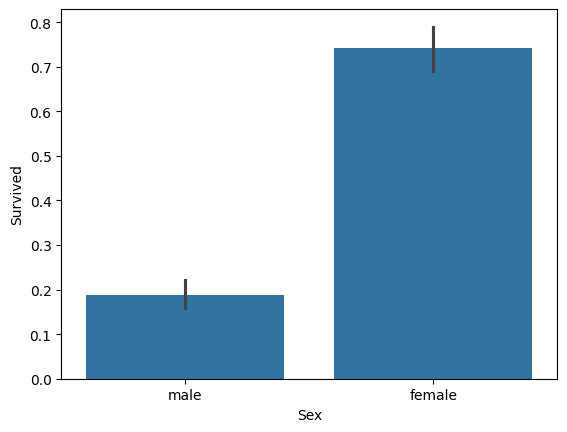

In [56]:
sns.barplot(x='Sex',y='Survived',data=titanic_df)

<Axes: xlabel='Pclass', ylabel='Survived'>

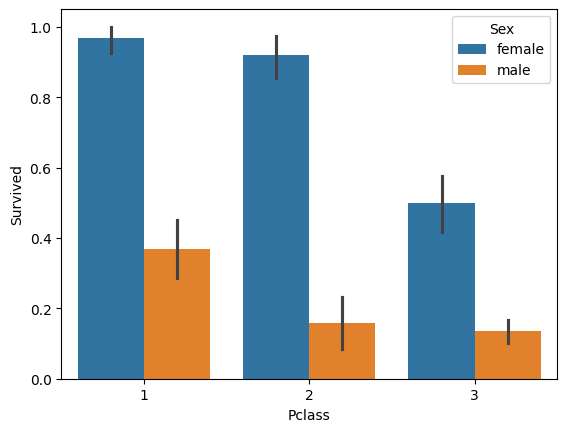

In [57]:
sns.barplot(x='Pclass',y='Survived',hue='Sex',data=titanic_df)

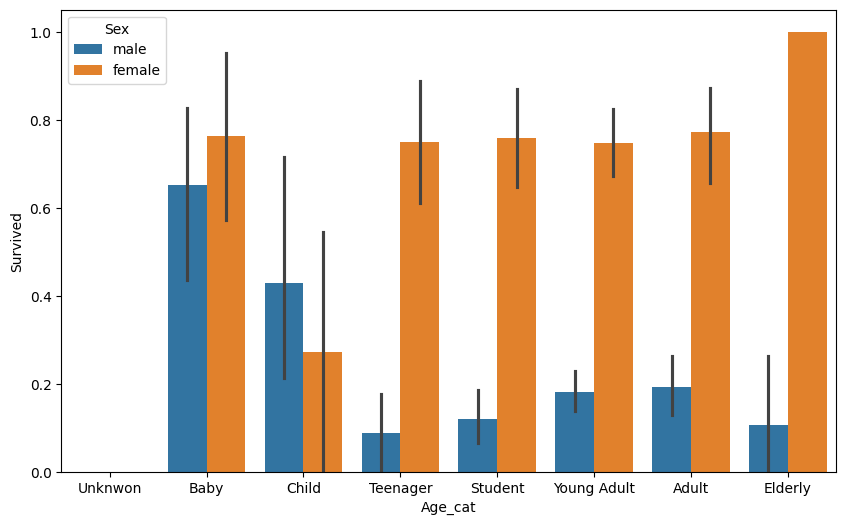

In [58]:
def get_category(age):
    cat=''
    if age<=-1:cat='Unknown'
    elif age<=5: cat='Baby'
    elif age<=12: cat='Child'
    elif age<=18: cat='Teenager'
    elif age<=25: cat='Student'
    elif age<=35: cat='Young Adult'
    elif age<=60: cat='Adult'
    else: cat='Elderly'

    return cat
plt.figure(figsize=(10,6))
group_names=['Unknwon','Baby','Child','Teenager','Student','Young Adult','Adult','Elderly']
titanic_df['Age_cat']=titanic_df['Age'].apply(lambda x: get_category(x))
sns.barplot(x='Age_cat',y='Survived',hue='Sex',data=titanic_df,order=group_names)
titanic_df.drop('Age_cat',axis=1,inplace=True)

In [59]:
from sklearn.preprocessing import LabelEncoder

def encode_features(dataDF):
    features=['Cabin','Sex','Embarked']
    for feature in features:
        le = LabelEncoder()
        le=le.fit(dataDF[feature])
        dataDF[feature]=le.transform(dataDF[feature])
    return dataDF
titanic_df=encode_features(titanic_df)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,7,3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,2,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,7,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2,3
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,7,3


In [60]:
def fillna(df):
    df['Age'].fillna(df['Age'].mean(),inplace=True)
    df['Cabin'].fillna('N',inplace=True)
    df['Embarked'].fillna('N',inplace=True)
    df['Fare'].fillna(0,inplace=True)
    return df
def drop_features(df):
    df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)
    return df
def format_features(df):
    df['Cabin']=df['Cabin'].str[:1]
    features = ['Cabin','Sex','Embarked']
    for feature in features:
        le=LabelEncoder()
        le=le.fit(df[feature])
        df[feature]=le.transform(df[feature])
    return df
def transform_features(df):
    df=fillna(df)
    df=drop_features(df)
    df=format_features(df)
    return df

In [61]:
titanic_df=pd.read_csv('train (3).csv')
y_titanic_df=titanic_df['Survived']
X_titanic_df=titanic_df.drop('Survived',axis=1)

X_titanic_df=transform_features(X_titanic_df)

In [68]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_titanic_df, y_titanic_df, test_size=0.2, random_state=11
)


In [69]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


dt_clf = DecisionTreeClassifier(random_state=11)
rf_clf = RandomForestClassifier(random_state=11)
lr_clf = LogisticRegression(solver='liblinear')


dt_clf.fit(X_train, y_train)
dt_pred = dt_clf.predict(X_test)
print('DecisionTreeClassifier 정확도: {0:.4f}'.format(accuracy_score(y_test, dt_pred)))

rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)
print('RandomForestClassifier 정확도: {0:.4f}'.format(accuracy_score(y_test, rf_pred)))

lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)
print('LogisticRegression 정확도: {0:.4f}'.format(accuracy_score(y_test, lr_pred)))


DecisionTreeClassifier 정확도: 0.7877
RandomForestClassifier 정확도: 0.8547
LogisticRegression 정확도: 0.8659


LogisticRegression이 가장 정확도가 높음

하지만 데이터 양 충분x, 최적화 작업x -> 어떤게 더 좋다 할 수 없음

교차검증으로 결정트리모델 평가하기

In [71]:
from sklearn.model_selection import KFold

def exec_kfold(clf,folds=5):
    kfold=KFold(n_splits=folds)
    scores=[]

    for iter_count,(train_index,test_index) in enumerate(kfold.split(X_titanic_df)):
        X_train,X_test=X_titanic_df.values[train_index],X_titanic_df.values[test_index]
        y_train,y_test=y_titanic_df.values[train_index],y_titanic_df.values[test_index]

        clf.fit(X_train,y_train)
        predictions=clf.predict(X_test)
        accuracy=accuracy_score(y_test,predictions)
        scores.append(accuracy)
        print("교차검증 {0} 정확도:{1:.4f}".format(iter_count,accuracy))
    mean_score=np.mean(scores)
    print("평균정확도:{0:.4f}".format(mean_score))
exec_kfold(dt_clf,folds=5)
    

교차검증 0 정확도:0.7542
교차검증 1 정확도:0.7809
교차검증 2 정확도:0.7865
교차검증 3 정확도:0.7697
교차검증 4 정확도:0.8202
평균정확도:0.7823


78.23%

In [74]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(dt_clf,X_titanic_df,y_titanic_df,cv=5)
for iter_count,accuracy in enumerate(scores):
    print("교차 검증{0}정확도: {1:.4f}".format(iter_count,accuracy))
print("평균 정확도:{0:.4f}".format(np.mean(scores)))

교차 검증0정확도: 0.7430
교차 검증1정확도: 0.7753
교차 검증2정확도: 0.7921
교차 검증3정확도: 0.7865
교차 검증4정확도: 0.8427
평균 정확도:0.7879


78.79%

stratifiedKFold이용해 폴드세트 분할해서 정확도가 약간 다름

In [75]:
from sklearn.model_selection import GridSearchCV

parameters={'max_depth':[2,3,5,10],
            'min_samples_split':[2,3,5],'min_samples_leaf':[1,5,8]}

grid_dclf=GridSearchCV(dt_clf,param_grid=parameters,scoring='accuracy',cv=5)
grid_dclf.fit(X_train,y_train)

print('GridSearchCV최적 하이퍼 파라미터:',grid_dclf.best_params_)
print('GridSearchCV 최고 정확도:{0:.4f}'.format(grid_dclf.best_score_))
best_dclf=grid_dclf.best_estimator_
dpredictions=best_dclf.predict(X_test)

GridSearchCV최적 하이퍼 파라미터: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
GridSearchCV 최고 정확도:0.7992


In [77]:
accuracy=accuracy_score(y_test,dpredictions)
print('테스트 세트에서의 DecisionTreeClassifier 정확도:{0:.4f}'.format(accuracy))

테스트 세트에서의 DecisionTreeClassifier 정확도:0.8715


87.15%